Monte Carlo Simulation

In [11]:
from scipy.stats import norm, lognorm
import numpy as np
import matplotlib.pyplot as plt


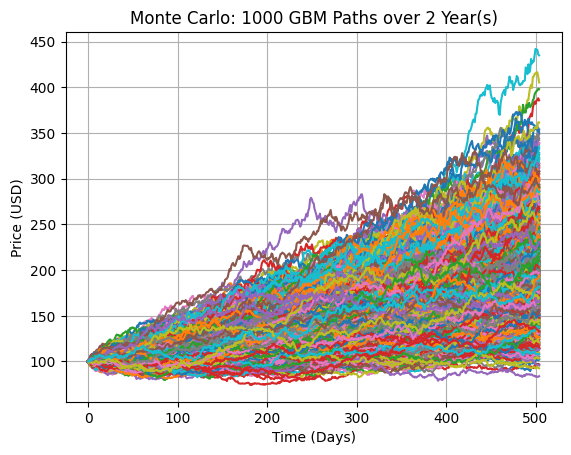

In [12]:
T = 2      # num years
shots = 1000
time = int(252 * T)
dt = 1 / 252  # 1 trading day
s0 = 100
mu = 0.34     # expected annual return
sigma = 0.18  # annual volatility

final_prices = []

for shot in range(shots):
    # Exact GBM discretisation (log-normal step) avoids Euler-Maruyama bias
    s = s0
    days = [0]
    price = [s0]

    for i in range(time):
        z = np.random.normal(0, 1)
        s = s * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
        days.append(i + 1)
        price.append(s)

    final_prices.append(s)
    plt.plot(days, price)

plt.xlabel("Time (Days)")
plt.ylabel("Price (USD)")
plt.title(f"Monte Carlo: {shots} GBM Paths over {T} Year(s)")
plt.grid(True)
plt.show()


In [13]:
# Empirical statistics from simulation
gain_count = sum(1 for p in final_prices if p > s0)
empirical_mean = np.mean(final_prices)
empirical_std = np.std(final_prices)

print(f"Chance of gain:  {100 * gain_count / shots:.1f}%")
print(f"Empirical Mean:  ${empirical_mean:.2f}")
print(f"Empirical Std:   ${empirical_std:.2f}")

# Sharpe ratio (excess return over risk-free rate, annualised)
risk_free_rate = 0.04  # adjust to current risk-free rate (e.g. 10-year Treasury yield)
returns = np.array(final_prices) / s0 - 1  # total return per path
annualised_returns = (1 + returns) ** (1 / T) - 1
sharpe_ratio = (np.mean(annualised_returns) - risk_free_rate) / np.std(annualised_returns)
print(f"Simulated Sharpe Ratio: {sharpe_ratio:.4f}")


Chance of gain:  99.5%
Empirical Mean:  $198.99
Empirical Std:   $50.79
Simulated Sharpe Ratio: 2.0368


Calculate Outcomes Through Lognormal Distribution

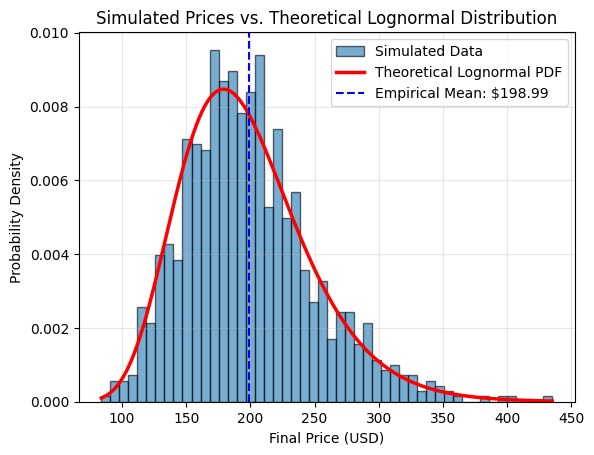

In [14]:
# log normal params
mu_log = np.log(s0) + (mu - (sigma**2) / 2) * T
sigma_log = sigma * np.sqrt(T)

# x axis
x_ax = np.linspace(min(final_prices), max(final_prices), 1000)

# log norm curve
pdf_curve = lognorm.pdf(x_ax, s=sigma_log, scale=np.exp(mu_log))

# plot results from sim
plt.hist(final_prices, bins=50, edgecolor='black', alpha=0.6, density=True, label='Simulated Data')

# plot real theoretical curve
plt.plot(x_ax, pdf_curve, color='red', linewidth=2.5, label='Theoretical Lognormal PDF')

plt.axvline(np.mean(final_prices), color='blue', linestyle='dashed', linewidth=1.5, label=f'Empirical Mean: ${np.mean(final_prices):.2f}')

plt.xlabel('Final Price (USD)')
plt.ylabel('Probability Density')
plt.title('Simulated Prices vs. Theoretical Lognormal Distribution')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Expectation Value and Chance of Gain

In [15]:
# Running sims every time is not practical
# Formula instead to calculate the expec values and chance of gain
# s0 = 100
# mu = 0.34
# sigma = 0.18
# T = 1 # 1 year

# expectation values
expected_value = s0 * np.exp(mu * T)
print(f"Exact Expected Value: ${expected_value:.2f}")



# z score
z_score = (mu - (sigma**2) / 2) * np.sqrt(T) / sigma

# Use the Normal CDF to find the probability
chance_of_gain = norm.cdf(z_score)
print(f"Exact Chance of Gain: {chance_of_gain * 100:.2f}%")

Exact Expected Value: $197.39
Exact Chance of Gain: 99.45%
